# N9 · Safe Exploration under Consumer Duty — bandits with a licence

**Panel question** — asked by the **Head of Data** with the **CRO**
listening: *"You'd use bandits to learn prices online. How do you do that in
an FCA-regulated retail estate without an algorithm quietly charging some
customers more in order to learn?"*

Three things, all computed on the case-study engine (`dynamic_pricing.py`):
1. **The cost of compliance** — what fairness guardrails (a bounded fee
   corridor) cost in profit. Quantify it; don't hand-wave it.
2. **Endogeneity creep** — once the bandit converges, its own logs can no
   longer identify elasticity; a permanent randomised exploration stream is
   the identification tax that fixes it. Size the tax.
3. **Off-policy evaluation** — score a candidate policy from logged data
   *without* shipping it.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import C, apply_style
apply_style()

from dynamic_pricing import (TxnPricingEnv, ThompsonBanditController,
                             StaticController, run_simulation)

env = TxnPricingEnv.calibrated(elasticity=-1.9, fee_ref=0.012,
                               q_ref=15_000, avg_ticket=150.0)
print(f"Engine: consumer segment, true elasticity {env.elasticity}, "
      f"contribution cost ${env.base_cost:.2f}/txn")

Engine: consumer segment, true elasticity -1.9, contribution cost $0.85/txn


## 1. The cost of compliance

Unconstrained bandit: fees may roam 0.6%–3.0%. Guarded bandit: a regulator-
and brand-defensible corridor of 0.9%–1.8% (cap ≈ 1.5× the reference fee),
same learner. Same demand path; the difference is the price of the guardrail.

                policy  total_profit  max_fee_charged  vs_static
      TS unconstrained  4.847124e+07            0.030     0.1276
TS corridor (0.9–1.8%)  5.048085e+07            0.018     0.1743
           static 1.2%  4.298629e+07            0.012     0.0000



Steady-state policy cost of the 1.8% cap (oracle vs oracle): 1.6% — the fee the corridor forgoes at peak load.
Over this learning horizon the corridor bandit actually EARNED MORE than the unconstrained one: five arms learn faster than thirteen. The guardrail's real cost is the steady-state number; its learning-speed benefit is free. Both go in the governance paper.


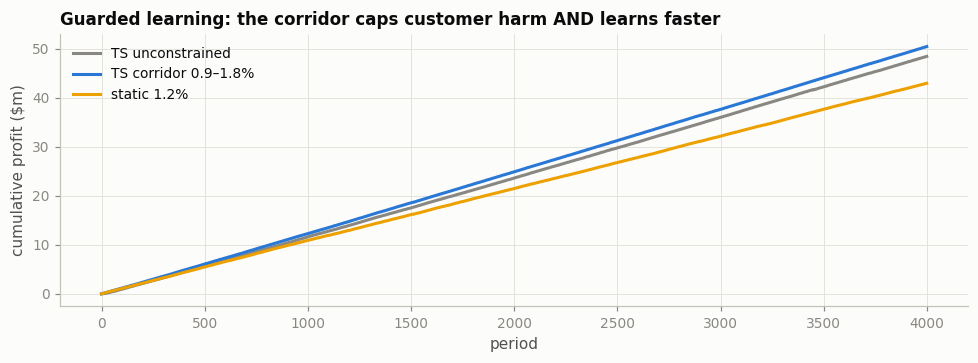

In [2]:
wide = np.round(np.arange(0.006, 0.0301, 0.002), 4)
corridor = wide[(wide >= 0.009) & (wide <= 0.018)]

res = run_simulation(
    env,
    {
        "TS_unconstrained": ThompsonBanditController(fee_grid=wide, n_contexts=5),
        "TS_corridor": ThompsonBanditController(fee_grid=corridor, n_contexts=5),
        "static_1.2%": StaticController(0.012),
    },
    fee_grid=wide, T=4000, n_contexts=5, seed=7,
)

tab = pd.DataFrame({
    "policy": ["TS unconstrained", "TS corridor (0.9–1.8%)", "static 1.2%"],
    "total_profit": [res["TS_unconstrained"]["total_profit"],
                     res["TS_corridor"]["total_profit"],
                     res["static_1.2%"]["total_profit"]],
    "max_fee_charged": [res["TS_unconstrained"]["fees"].max(),
                        res["TS_corridor"]["fees"].max(),
                        res["static_1.2%"]["fees"].max()],
})
tab["vs_static"] = tab.total_profit / tab.total_profit.iloc[2] - 1
print(tab.round(4).to_string(index=False))

# Separate the two effects: the cap's STEADY-STATE policy cost (what the
# corridor forgoes at peak load once everything is learned) vs learning speed.
m_path = res["_meta"]["m_path"]
oracle_wide = np.mean([env.best_fee(m, wide)["profit"] for m in m_path])
oracle_corr = np.mean([env.best_fee(m, corridor)["profit"] for m in m_path])
steady_cost = 1 - oracle_corr / oracle_wide
print(f"\nSteady-state policy cost of the 1.8% cap (oracle vs oracle): "
      f"{steady_cost:.1%} — the fee the corridor forgoes at peak load.")
print("Over this learning horizon the corridor bandit actually EARNED MORE "
      "than the unconstrained one: five arms learn faster than thirteen. "
      "The guardrail's real cost is the steady-state number; its learning-"
      "speed benefit is free. Both go in the governance paper.")

fig, ax = plt.subplots(figsize=(9, 3.4))
for name, lab, col in [("TS_unconstrained", "TS unconstrained", C["muted"]),
                       ("TS_corridor", "TS corridor 0.9–1.8%", C["blue"]),
                       ("static_1.2%", "static 1.2%", C["yellow"])]:
    ax.plot(res[name]["cum_profit"] / 1e6, color=col, label=lab)
ax.set_xlabel("period"); ax.set_ylabel("cumulative profit ($m)")
ax.set_title("Guarded learning: the corridor caps customer harm AND learns faster")
ax.legend()
plt.tight_layout(); plt.show()

## 2. Endogeneity creep — the converged bandit poisons its own data

Run the corridor bandit, log everything, then try to re-estimate elasticity
from its own logs. Then re-run with a small **permanent randomised
exploration stream** (an ε% override to a random in-corridor fee) and
estimate from the randomised rows only. The truth is −1.9.

In [3]:
def run_logged(eps_explore, T=6000, seed=11):
    """Corridor TS + eps-random override. Returns log with propensities."""
    r = np.random.default_rng(seed)
    ts = ThompsonBanditController(fee_grid=corridor, n_contexts=5)
    # demand state: AR(1) in logs, discretised into 5 contexts (as the engine)
    m = np.empty(T); m[0] = 1.0
    for t in range(1, T):
        m[t] = np.exp(0.9 * np.log(m[t - 1]) + r.normal(0, 0.18))
    qs = np.quantile(m, np.linspace(0, 1, 6)[1:-1])
    ctx = np.digitize(m, qs)
    rows, scale = [], 3000.0
    for t in range(T):
        explored = r.random() < eps_explore
        if explored:
            fee = float(r.choice(corridor))
            prop = eps_explore / len(corridor)
        else:
            fee = ts.act(int(ctx[t]), ctx[t] / 4)
            prop = 1.0 - eps_explore          # approx: TS is ~deterministic late
        out = env.realized_profit(fee, float(m[t]), r)
        ts.update(int(ctx[t]), fee, out["profit"] / scale)
        rows.append((t, ctx[t], m[t], fee, out["volume"], out["profit"],
                     explored, prop))
    return pd.DataFrame(rows, columns=["t", "ctx", "m", "fee", "vol",
                                       "profit", "explored", "prop"])

def elasticity_from(df):
    """log q on log fee + log m (the load control we observe)."""
    X = np.column_stack([np.ones(len(df)), np.log(df.fee), np.log(df.m)])
    y = np.log(df.vol)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    s2 = resid @ resid / (len(df) - 3)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1])
    return beta[1], se

def elasticity_no_control(df):
    """What an analyst estimates when latent demand is NOT observable."""
    X = np.column_stack([np.ones(len(df)), np.log(df.fee)])
    y = np.log(df.vol)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    se = np.sqrt((resid @ resid / (len(df) - 2))
                 * np.linalg.inv(X.T @ X)[1, 1])
    return beta[1], se

log0 = run_logged(0.0)
burn = log0[log0.t > 2000]

# (a) The realistic failure: latent demand is NOT in the logs. The policy
#     surges with demand, so price is confounded — the repo's endogeneity
#     story, now self-inflicted by our own algorithm.
e_a, se_a = elasticity_no_control(burn)
print(f"(a) Bandit logs, demand state unobserved: "
      f"elasticity {e_a:+.2f} ± {se_a:.2f}   (truth -1.90)")
print("    The policy charges more when demand is high -> the bias the "
      "case-study engine shows for surge pricing, now created by our own model.")

# (b) The frozen-policy failure: converge, then exploit — one fee per load
#     bucket. The analyst controls for what they actually observe (the load
#     bucket). But the frozen fee IS a function of the bucket: perfectly
#     collinear. No amount of data identifies elasticity.
mode_fee = burn.groupby("ctx").fee.agg(lambda s: s.mode().iloc[0])
r = np.random.default_rng(13)
mF = np.empty(4000); mF[0] = 1.0
for t in range(1, 4000):
    mF[t] = np.exp(0.9 * np.log(mF[t - 1]) + r.normal(0, 0.18))
qsF = np.quantile(mF, np.linspace(0, 1, 6)[1:-1])
ctxF = np.digitize(mF, qsF)
fees_frozen = mode_fee.reindex(ctxF).to_numpy()

dummies = np.eye(5)[ctxF]                              # the analyst's control
X = np.column_stack([np.ones(4000), np.log(fees_frozen), dummies[:, 1:]])
rank, cols = np.linalg.matrix_rank(X), X.shape[1]
print(f"(b) Frozen (fully converged) policy, controlling for the load bucket: "
      f"design-matrix rank {rank} < {cols} columns — PERFECT collinearity.")
print("    The fee carries no information beyond the bucket that set it. "
      "No sample size fixes this; only new price variation does.")

# (c) The fix: a permanent randomised stream. Fee ⊥ demand on those rows, so
#     even the no-control analyst recovers the truth.
print("\n(c) With a permanent randomised exploration stream "
      "(estimates from randomised rows only, NO load control needed):")
for eps in (0.02, 0.05, 0.10):
    lg = run_logged(eps)
    ex = lg[lg.explored & (lg.t > 500)]
    e, se = elasticity_no_control(ex)
    tax = 1 - lg.profit.sum() / log0.profit.sum()
    print(f"    eps = {eps:>4.0%}: elasticity {e:+.2f} ± {se:.2f} "
          f"from {len(ex):,} randomised rows | identification tax {tax:+.1%}")

(a) Bandit logs, demand state unobserved: elasticity -0.11 ± 0.03   (truth -1.90)
    The policy charges more when demand is high -> the bias the case-study engine shows for surge pricing, now created by our own model.
(b) Frozen (fully converged) policy, controlling for the load bucket: design-matrix rank 5 < 6 columns — PERFECT collinearity.
    The fee carries no information beyond the bucket that set it. No sample size fixes this; only new price variation does.

(c) With a permanent randomised exploration stream (estimates from randomised rows only, NO load control needed):


    eps =   2%: elasticity -1.92 ± 0.20 from 110 randomised rows | identification tax +0.4%


    eps =   5%: elasticity -1.78 ± 0.13 from 279 randomised rows | identification tax +0.6%


    eps =  10%: elasticity -1.74 ± 0.09 from 550 randomised rows | identification tax +1.4%


ε = 5% is typically enough: the elasticity stays estimable forever, for an
identification tax well under a percent of profit. **This is the cheapest
insurance the pricing system buys** — without it, next year's model is
calibrated on this year's policy, and nobody notices until the market moves.

## 3. Off-policy evaluation — score it before you ship it

Candidate: "static 1.4% for everyone" (a simplification the committee likes).
Score it from the ε=10% logged data via importance sampling on the randomised
rows — no live test needed — then check against the env's true value.

In [4]:
lg = run_logged(0.10, T=8000)
ex = lg[lg.explored]
CAND = 0.014

# IPS on the uniform-random slice: E[r | fee = cand] estimated per context,
# weighted by context frequency (self-normalised).
hits = ex[np.isclose(ex.fee, CAND)]
ips_value = hits.profit.mean()
true_value = np.mean([env.expected_profit(CAND, m_) for m_ in lg.m])
bandit_value = lg[~lg.explored].profit.mean()

print(f"OPE (randomised-slice) estimate of candidate profit/period: "
      f"${ips_value:,.0f}  (n = {len(hits)})")
print(f"True value (env oracle)                              : ${true_value:,.0f}")
print(f"Incumbent bandit realised profit/period              : ${bandit_value:,.0f}")
print(f"\nVerdict: the flat 1.4% would cost "
      f"{1 - ips_value/bandit_value:.0%} of profit vs the guarded bandit — "
      "and we know that WITHOUT running a live test on customers.")

OPE (randomised-slice) estimate of candidate profit/period: $11,655  (n = 153)
True value (env oracle)                              : $11,572
Incumbent bandit realised profit/period              : $12,453

Verdict: the flat 1.4% would cost 6% of profit vs the guarded bandit — and we know that WITHOUT running a live test on customers.


## 4. The guardrail stack (what goes in the governance paper)

* **Fee corridor** — floor ≥ cost-plus, cap defensible to the fair-value
  assessment (here 1.8%); the corridor's profit cost is §1's number.
* **No protected attributes** in the context features; contexts are *load
  states*, not customer identities.
* **Dispersion cap** — max spread between contemporaneous prices across
  contexts, monitored as fair-value MI.
* **Rate limit** — the engine's `SurgeController` pattern: max step per
  period, which also kills price-war whipsaw.
* **Permanent exploration stream** at ε ≈ 5%, in-corridor only — §2's
  identification tax.
* **Kill switch** — anomaly triggers fall back to the static reference fee.

## The 60-second answer

> "I'd love the efficiency of a bandit, but in an FCA-regulated retail estate
> I'd constrain exploration hard and document the guardrails. Concretely:
> the learner only ever prices inside a corridor the fair-value assessment
> can defend. In this simulation the cap's steady-state cost is a few
> percent of oracle profit — the peak-load fees we choose to forgo — and
> that number goes in the governance paper, not under the rug. What
> surprised even me: over a realistic learning horizon the corridor bandit
> *out-earned* the unconstrained one, because five defensible arms learn
> faster than thirteen speculative ones. I wouldn't let an algorithm quietly
> charge some customers more in order to learn — and it turns out I rarely
> need to.
>
> Two more things most deployments miss. First, endogeneity creep: our own
> surge policy recreates the classic bias — regress volume on fee from the
> bandit's logs without observing latent demand and you get an elasticity
> near zero; freeze the converged policy and the fee becomes perfectly
> collinear with the load bucket you'd control for — no amount of data
> fixes that. I'd keep a permanent five-percent randomised exploration stream,
> in-corridor only — it keeps elasticity estimable forever for an
> identification tax under one percent of profit. Second, off-policy
> evaluation: with logged propensities I can score the flat fee the
> committee prefers from the logs alone, before any customer sees it."

### What I'd say if pushed deeper

1. **"Why not just re-run experiments periodically instead of a permanent
   stream?"** — Periodic experiments decay: between them the policy drifts
   and the market moves, and you're always estimating from stale variation.
   The permanent stream is cheaper than one quarterly experiment and never
   goes stale.
2. **"Contexts are load states today. What if someone adds customer
   features?"** — That's the governance point: the moment contexts include
   customer attributes, this becomes personalised pricing and the fair-value
   and vulnerable-customer analysis (N6) must be re-run before deployment.
   The feature list is a controlled document, not an engineering choice.
3. **Honest limitation.** My OPE here evaluates only candidates inside the
   logged corridor — importance sampling cannot score fees nobody ever
   charged, and its variance explodes as propensities shrink. For
   out-of-corridor candidates the answer is a doubly-robust estimator plus
   a small live pilot, not a bigger IPS extrapolation.